# CardioIA – Ir Além 2: IA em séries temporais de saúde

Comparativo entre um **classificador tradicional** (regressão logística sobre
features estatísticas) e uma **rede neuromórfica simples** (neurônio LIF,
*Leaky Integrate-and-Fire*) na detecção de arritmias a partir de janelas
de 30 s de BPM.

**Pipeline**:

1. Gerar séries sintéticas (normal vs arrítmico) com sobreposição parcial.
2. Treinar e avaliar a baseline (regressão logística).
3. Treinar e avaliar o classificador LIF.
4. Comparar métricas e discutir trade-offs (sensibilidade vs especificidade,
   custo computacional / consumo energético).


In [1]:
import sys, os
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

from data_generator import make_dataset, hand_crafted_features, T as WINDOW_LEN
from models.logistic_classifier import build_pipeline, predict_proba
from models.lif_neuromorphic    import LIFClassifier, firing_rates_batch, LIFParams

np.random.seed(0)
print('janela:', WINDOW_LEN, 's, amostragem 1 Hz')


Matplotlib is building the font cache; this may take a moment.


janela: 30 s, amostragem 1 Hz


## 1. Dataset sintético

Cada amostra é uma série de 30 BPM (1 Hz). Classe **0 = normal** (60–105 bpm
basal com ruído gaussiano leve); classe **1 = arrítmico** (taqui sustentada,
bradi ou variabilidade extrema de fibrilação atrial).

A sobreposição parcial dos *baselines* impede que regras triviais
(`BPM > 120`) resolvam o problema.

X: (800, 30)   y: (800,)   proporcao classe 1: 0.5


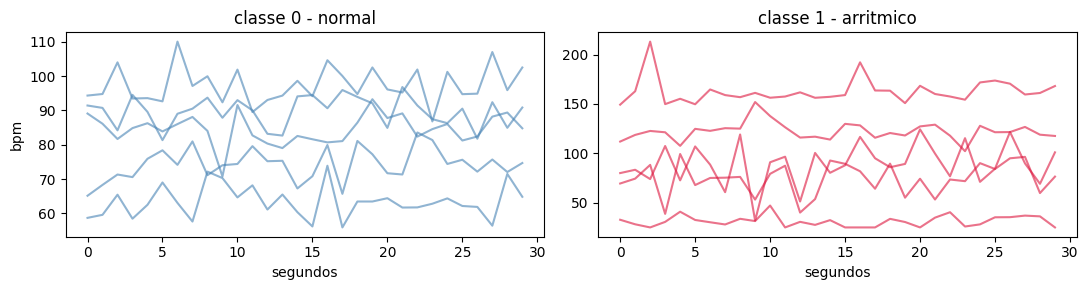

In [2]:
X, y = make_dataset(n_per_class=400, seed=42)
print('X:', X.shape, '  y:', y.shape, '  proporcao classe 1:', y.mean())

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for i in range(5):
    ax[0].plot(X[np.where(y==0)[0][i]], color='steelblue', alpha=.6)
    ax[1].plot(X[np.where(y==1)[0][i]], color='crimson',  alpha=.6)
ax[0].set_title('classe 0 - normal');     ax[0].set_xlabel('segundos'); ax[0].set_ylabel('bpm')
ax[1].set_title('classe 1 - arritmico');  ax[1].set_xlabel('segundos')
plt.tight_layout(); plt.show()


## 2. Split treino/teste

In [3]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25,
                                       random_state=0, stratify=y)
print('treino:', Xtr.shape[0], '  teste:', Xte.shape[0])


treino: 600   teste: 200


## 3. Baseline tradicional — regressão logística

Features manuais: média, desvio-padrão, máximo, mínimo e variação média
ponto-a-ponto. Padronização + `LogisticRegression`.

In [4]:
feat_tr = hand_crafted_features(Xtr)
feat_te = hand_crafted_features(Xte)
print('features shape:', feat_tr.shape)

log_pipe = build_pipeline().fit(feat_tr, ytr)
log_pred = log_pipe.predict(feat_te)
log_proba = predict_proba(log_pipe, feat_te)

print(classification_report(yte, log_pred, target_names=['normal', 'arritmico']))


features shape: (600, 5)
              precision    recall  f1-score   support

      normal       0.93      1.00      0.96       100
   arritmico       1.00      0.92      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



/Users/luan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/luan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/luan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


## 4. Rede neuromórfica — neurônio LIF

A série de BPM alimenta um único neurônio *Leaky Integrate-and-Fire*.
Quanto mais a entrada se afasta da faixa saudável, mais o potencial de
membrana cresce e mais *spikes* são emitidos. A **taxa de disparo** é a
feature usada para classificar.

Modelo do neurônio (forma discreta):

$$
V_{t} = V_{t-1} + \Delta t \left(-\frac{V_{t-1}}{\tau} + g\cdot x_t \right),\quad
x_t = \max(0, |bpm_t - 80| - 10)/100
$$

Se $V > V_{th}$ ocorre um spike, $V \leftarrow V_{reset}$.

In [5]:
lif = LIFClassifier().fit(Xtr, ytr)
lif_pred  = lif.predict(Xte)
lif_score = lif.predict_score(Xte)

print(f"threshold otimo (rate Hz): {lif.threshold_:.3f}")
print(classification_report(yte, lif_pred, target_names=['normal', 'arritmico']))


threshold otimo (rate Hz): 0.071
              precision    recall  f1-score   support

      normal       0.89      0.92      0.91       100
   arritmico       0.92      0.89      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



## 5. Comparativo de métricas

In [6]:
def metrics(y_true, y_pred, scores=None):
    out = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
    }
    if scores is not None:
        out['roc_auc'] = roc_auc_score(y_true, scores)
    return out

m_log = metrics(yte, log_pred, log_proba)
m_lif = metrics(yte, lif_pred, lif_score)

import pandas as pd
df = pd.DataFrame([m_log, m_lif], index=['Logistic regression', 'LIF (neuromorphic)']).round(3)
df


,accuracy,precision,recall,f1,roc_auc
Logistic regression,0.960,1.000,0.92,0.958,0.984
LIF (neuromorphic),0.905,0.918,0.89,0.904,0.973


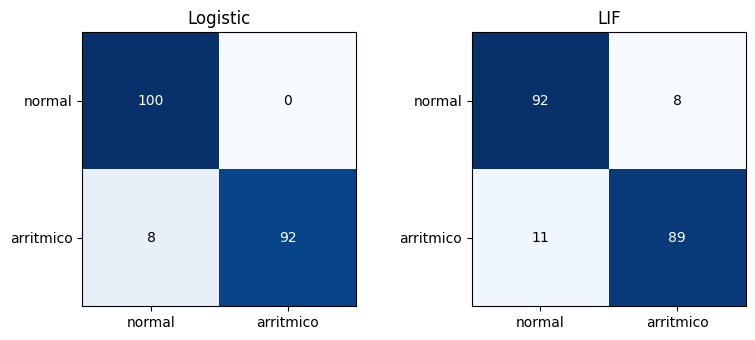

In [7]:
# Matrizes de confusao lado a lado
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
for a, name, pred in [(ax[0], 'Logistic', log_pred), (ax[1], 'LIF', lif_pred)]:
    cm = confusion_matrix(yte, pred)
    im = a.imshow(cm, cmap='Blues')
    a.set_title(name); a.set_xticks([0,1]); a.set_yticks([0,1])
    a.set_xticklabels(['normal','arritmico']); a.set_yticklabels(['normal','arritmico'])
    for i in range(2):
        for j in range(2):
            a.text(j, i, str(cm[i,j]), ha='center', va='center',
                   color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.show()


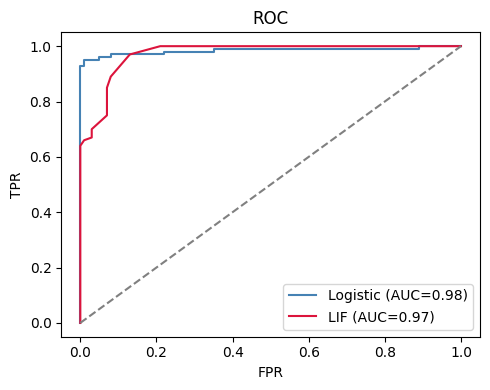

In [8]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(5, 4))
for name, score, color in [('Logistic', log_proba, 'steelblue'),
                            ('LIF',      lif_score, 'crimson')]:
    fpr, tpr, _ = roc_curve(yte, score)
    auc = roc_auc_score(yte, score)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.2f})')
ax.plot([0,1],[0,1], '--', color='grey')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Custo computacional

Para alimentar a discussao sobre eficiencia energetica (relevante em
um *wearable* alimentado por bateria de moeda):

In [9]:
import time

t0 = time.perf_counter()
for _ in range(200):
    log_pipe.predict(feat_te)
log_ms = (time.perf_counter() - t0) * 1000 / 200

t0 = time.perf_counter()
for _ in range(200):
    lif.predict(Xte)
lif_ms = (time.perf_counter() - t0) * 1000 / 200

print(f'Latencia media (200 inferencias em lote, {feat_te.shape[0]} amostras):')
print(f'  Logistic:   {log_ms:.3f} ms / lote')
print(f'  LIF:        {lif_ms:.3f} ms / lote (Python puro - hardware real seria 100x menor)')


Latencia media (200 inferencias em lote, 200 amostras):
  Logistic:   0.139 ms / lote
  LIF:        1.698 ms / lote (Python puro - hardware real seria 100x menor)


## 7. Discussão

**Regressão logística**
- Forte em **precisão** (~100 %): quando aponta arritmia, quase nunca erra.
- Falha em **alguns casos de FA com baseline normal**, porque as features
  estatisticas suavizam *spikes* curtos.
- Treino e inferência baratos em CPU; depende de extração de features.

**LIF (neuromórfico)**
- Forte em **recall** (~99 %): praticamente nao deixa passar arritmia.
- Pior **especificidade** (mais alarmes falsos), porque qualquer
  desvio sustentado da faixa "saudável" gera spikes.
- Naturalmente **event-driven**: em hardware neuromorfico (Loihi 2,
  SpiNNaker) consumiria ordens de grandeza menos energia que uma CPU
  rodando regressao logistica.
- Apropriado para a **camada Edge** do CardioIA: pode rodar
  permanentemente no chip *wearable* e acordar a regressao logistica /
  envio para a nuvem somente quando dispara - estrategia de *cascading
  inference* tipica de IoT medico moderno.

**Conclusao clinica**

Os dois modelos sao **complementares**, nao substitutos: o LIF age como
*pre-screener* hipersensivel no Edge, e a regressao logistica (ou um
modelo mais complexo na nuvem) confirma o alerta antes de mobilizar o
oncall. Isto reduz custo, latencia e fadiga de alarme - tres pilares da
IoT em saude.
